<a href="https://colab.research.google.com/github/snehasawant054-design/CSL701-CE-43_Machine-learning-lab/blob/main/Experiments/Experiment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sneha Baburao Sawant
CE-43

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:

# Path of uploaded ZIP file
zip_path = '/content/cardekho_dataset.csv.zip'

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cardekho_data')

# Check extracted files
print("Extracted files:")
print(os.listdir('/content/cardekho_data'))

# Load the CSV file
df = pd.read_csv('/content/cardekho_data/cardekho_dataset.csv')

# Display first 5 records
print("\nFirst 5 records:")
print(df.head())

# Number of rows and columns
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Identify numerical attributes
numerical_cols = df.select_dtypes(include='number').columns.tolist()

# Identify categorical attributes
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical attributes:")
print(numerical_cols)

print("\nCategorical attributes:")
print(categorical_cols)

# Separate Selling Price as target variable
y = df['selling_price']

# Separate predictor variables
X = df.drop('selling_price', axis=1)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Extracted files:
['cardekho_dataset.csv']

First 5 records:
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selli

## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values found.")

Missing values per column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

No missing values found.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
X = X.drop(columns=['Unnamed: 0', 'car_name'])

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Selected features:")
print(X.head())

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

final_features = numerical_cols + categorical_cols
print("\nFinal features:")
print(final_features)

Selected features:
     brand     model  vehicle_age  km_driven seller_type fuel_type  \
0   Maruti      Alto            9     120000  Individual    Petrol   
1  Hyundai     Grand            5      20000  Individual    Petrol   
2  Hyundai       i20           11      60000  Individual    Petrol   
3   Maruti      Alto            9      37000  Individual    Petrol   
4     Ford  Ecosport            6      30000      Dealer    Diesel   

  transmission_type  mileage  engine  max_power  seats  
0            Manual    19.70     796      46.30      5  
1            Manual    18.90    1197      82.00      5  
2            Manual    17.00    1197      80.00      5  
3            Manual    20.92     998      67.10      5  
4            Manual    22.77    1498      98.59      5  

Numerical columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Categorical columns:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Final features:
['vehicle_age', 'km

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
categorical_cols_to_encode = [
    'brand',
    'model',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

X = pd.get_dummies(
    X,
    columns=categorical_cols_to_encode,
    drop_first=True
)

print("Data types after encoding:")
print(X.dtypes.value_counts())

print("\nFirst 5 rows:")
print(X.head())

print("\nShape of X:", X.shape)

Data types after encoding:
bool       157
int64        4
float64      2
Name: count, dtype: int64

First 5 rows:
   vehicle_age  km_driven  mileage  engine  max_power  seats  brand_BMW  \
0            9     120000    19.70     796      46.30      5      False   
1            5      20000    18.90    1197      82.00      5      False   
2           11      60000    17.00    1197      80.00      5      False   
3            9      37000    20.92     998      67.10      5      False   
4            6      30000    22.77    1498      98.59      5      False   

   brand_Bentley  brand_Datsun  brand_Ferrari  ...  model_i10  model_i20  \
0          False         False          False  ...      False      False   
1          False         False          False  ...      False      False   
2          False         False          False  ...      False       True   
3          False         False          False  ...      False      False   
4          False         False          False  ...      

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
print("The dataset already contains 'vehicle_age'.")

print("\nVehicle age statistics:")
print(X['vehicle_age'].describe())

print("\nThe vehicle_age column will be retained as a feature.")

The dataset already contains 'vehicle_age'.

Vehicle age statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: vehicle_age, dtype: float64

The vehicle_age column will be retained as a feature.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

Scatter plots between numerical predictors and Selling Price.


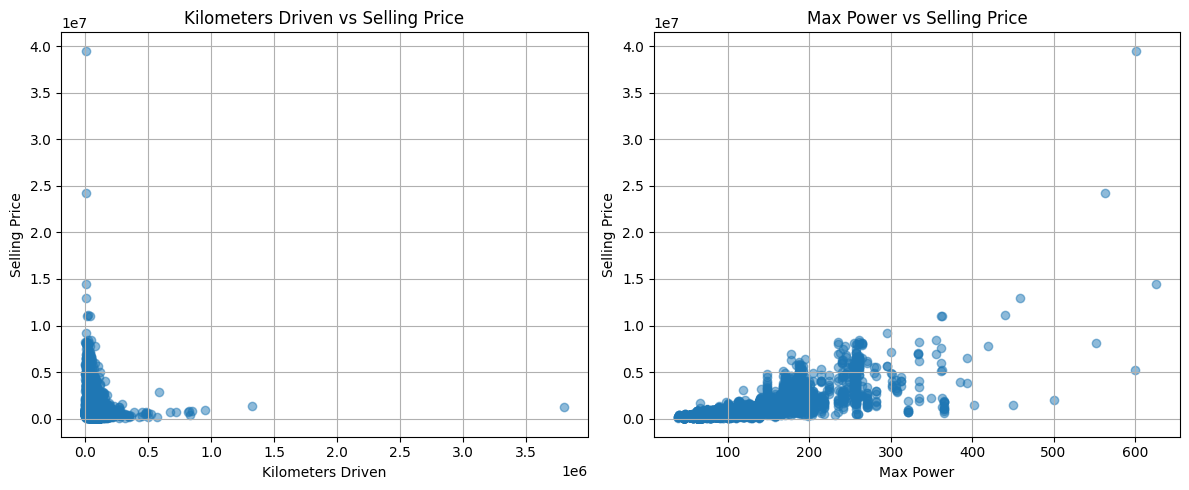

In [ ]:
print("Scatter plots between numerical predictors and Selling Price.")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X['km_driven'], y, alpha=0.5)
plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X['max_power'], y, alpha=0.5)
plt.title('Max Power vs Selling Price')
plt.xlabel('Max Power')
plt.ylabel('Selling Price')
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:

from sklearn.model_selection import train_test_split

# Split first so that standardization uses training data only
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_standardized = X_train.copy()
X_test_standardized = X_test.copy()

for col in numerical_cols:

    mean_train = X_train_standardized[col].mean()
    std_train = X_train_standardized[col].std()

    X_train_standardized[col] = (
        X_train_standardized[col] - mean_train
    ) / std_train

    X_test_standardized[col] = (
        X_test_standardized[col] - mean_train
    ) / std_train

X_train = X_train_standardized
X_test = X_test_standardized

print("Training data after standardization:")
print(X_train[numerical_cols].head())

print("\nTesting data after standardization:")
print(X_test[numerical_cols].head())

Training data after standardization:
       vehicle_age  km_driven   mileage    engine  max_power     seats
11210     0.323956   0.349086 -2.050736  1.756693   2.681577 -0.403807
1347     -1.337744  -1.069350  0.985621 -0.547059  -0.382729 -0.403807
10363    -1.337744  -1.163517 -0.177035  0.893506   3.296777 -0.403807
316       0.323956   0.178361 -0.465296  0.024563   0.396213 -0.403807
10638     1.320976   0.585445  0.149662 -0.550895  -0.502026 -0.403807

Testing data after standardization:
       vehicle_age  km_driven   mileage    engine  max_power     seats
3334      1.985656   0.413779  0.149662 -0.550895  -0.502026 -0.403807
10928    -0.673064   0.060653  1.838395 -0.453067  -0.616645 -0.403807
2518      0.323956   0.955238  0.248151 -0.453067  -0.271385  2.070416
11322    -1.670084  -1.198830 -0.321166  0.026482   0.444166 -0.403807
9394      1.653316   0.154820 -0.008882 -1.320091  -1.264594 -0.403807


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
print("Number of observations in training set:", X_train.shape[0])
print("Number of observations in testing set:", X_test.shape[0])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Number of observations in training set: 12328
Number of observations in testing set: 3083
Shape of X_train: (12328, 163)
Shape of X_test: (3083, 163)
Shape of y_train: (12328,)
Shape of y_test: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of predictor columns:", X_train.shape[1])

X_train shape: (12328, 163)
y_train shape: (12328,)
X_test shape: (3083, 163)
y_test shape: (3083,)

Number of predictor columns: 163


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:

X_train_with_bias = np.insert(
    X_train.to_numpy().astype(float),
    0,
    1,
    axis=1
)

X_test_with_bias = np.insert(
    X_test.to_numpy().astype(float),
    0,
    1,
    axis=1
)

y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

print("X_train with bias:", X_train_with_bias.shape)
print("X_test with bias:", X_test_with_bias.shape)
print("y_train:", y_train_np.shape)
print("y_test:", y_test_np.shape)

X_train with bias: (12328, 164)
X_test with bias: (3083, 164)
y_train: (12328, 1)
y_test: (3083, 1)


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
def ols_function(X_matrix, y_vector):

    Xt_X = X_matrix.T @ X_matrix

    Xt_y = X_matrix.T @ y_vector

    Xt_X_inv = np.linalg.pinv(Xt_X)

    beta_hat = Xt_X_inv @ Xt_y

    return beta_hat


print("OLS function created successfully.")

OLS function created successfully.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
Xt_X_train = X_train_with_bias.T @ X_train_with_bias

determinant = np.linalg.det(Xt_X_train)

print("Determinant:", determinant)

if np.isclose(determinant, 0):
    print("\nMatrix is singular or nearly singular.")
    print("Possible multicollinearity or redundant features.")
else:
    print("\nMatrix is not singular.")
    print("OLS can proceed.")

Determinant: 0.0

Matrix is singular or nearly singular.
Possible multicollinearity or redundant features.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
beta_hat = ols_function(
    X_train_with_bias,
    y_train_np
)

print("Regression Coefficients:")

print("Intercept:", beta_hat[0][0])

feature_names = X_train.columns.tolist()

full_feature_names = ['Intercept'] + feature_names

for i in range(1, len(beta_hat)):

    feature_name = full_feature_names[i]

    print(
        feature_name,
        ":",
        beta_hat[i][0]
    )

Regression Coefficients:
Intercept: 2906728.3525575474
vehicle_age : -232532.07456261833
km_driven : -40013.468018797954
mileage : -12513.858381381724
engine : -120404.20322912745
max_power : 244596.3069831133
seats : -22229.242256815545
brand_BMW : -1455148.3607334886
brand_Bentley : 2383582.455776781
brand_Datsun : -1931237.9235543162
brand_Ferrari : 16924712.130069584
brand_Force : -980371.9684664011
brand_Ford : -1762491.3351514265
brand_Honda : -1827145.0488735698
brand_Hyundai : -2007489.0431641024
brand_ISUZU : -664081.925320833
brand_Isuzu : -937478.0190534219
brand_Jaguar : 63657.16589945514
brand_Jeep : -117864.67425498553
brand_Kia : -822232.1178833013
brand_Land Rover : 192849.78302333783
brand_Lexus : 1489530.066778373
brand_MG : -902667.8128976356
brand_Mahindra : -1839975.5321666487
brand_Maruti : -2216820.418814808
brand_Maserati : 1547862.3418926746
brand_Mercedes-AMG : -4.0136030799364227e-07
brand_Mercedes-Benz : 19965.517892238684
brand_Mini : -426091.9045655187
bra

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
coefficients_df = pd.DataFrame({
    'Feature': full_feature_names,
    'Coefficient': beta_hat.flatten()
})

coefficients_df['Abs_Coefficient'] = np.abs(
    coefficients_df['Coefficient']
)

coefficients_df_sorted = coefficients_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print("Regression coefficients sorted by influence:")

display(coefficients_df_sorted)

Regression coefficients sorted by influence:


,Feature,Coefficient,Abs_Coefficient
87,model_GTC4Lusso,1.692471e+07,1.692471e+07
10,brand_Ferrari,1.692471e+07,1.692471e+07
89,model_Ghost,9.794549e+06,9.794549e+06
32,brand_Rolls-Royce,9.794549e+06,9.794549e+06
142,model_X4,3.263559e+06,3.263559e+06
...,...,...,...
157,seller_type_Individual,-1.579509e+04,1.579509e+04
3,mileage,-1.251386e+04,1.251386e+04
26,brand_Mercedes-AMG,-4.013603e-07,4.013603e-07
52,model_C,2.716045e-08,2.716045e-08


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
y_pred_test_np = X_test_with_bias @ beta_hat

y_pred_test = y_pred_test_np.flatten()

comparison_df = pd.DataFrame({
    'Actual Selling Price': y_test_np.flatten(),
    'Predicted Selling Price': y_pred_test
})

print("Actual vs Predicted Selling Prices:")

display(comparison_df.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,190000,7.125788e+04
1,600000,6.151970e+05
2,665000,6.254916e+05
3,1570000,1.222561e+06
4,160000,-5.582842e+04
5,675000,4.326672e+05
6,465000,3.197938e+05
7,260000,2.524556e+05
8,300000,3.601658e+05
9,850000,1.837191e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
residuals = y_test_np - y_pred_test_np

rss = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(rss)

print("\nInterpretation:")
print("Lower RSS indicates smaller prediction errors.")

Residual Sum of Squares (RSS):
464368615292575.9

Interpretation:
Lower RSS indicates smaller prediction errors.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
y_test_mean = np.mean(y_test_np)

TSS = np.sum(
    (y_test_np - y_test_mean) ** 2
)

r_squared = 1 - (rss / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR-squared:")
print(r_squared)

print(
    "\nPercentage of variability explained:",
    r_squared * 100,
    "%"
)

Total Sum of Squares (TSS):
2320826260059733.0

R-squared:
0.7999123746210007

Percentage of variability explained: 79.99123746210007 %


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


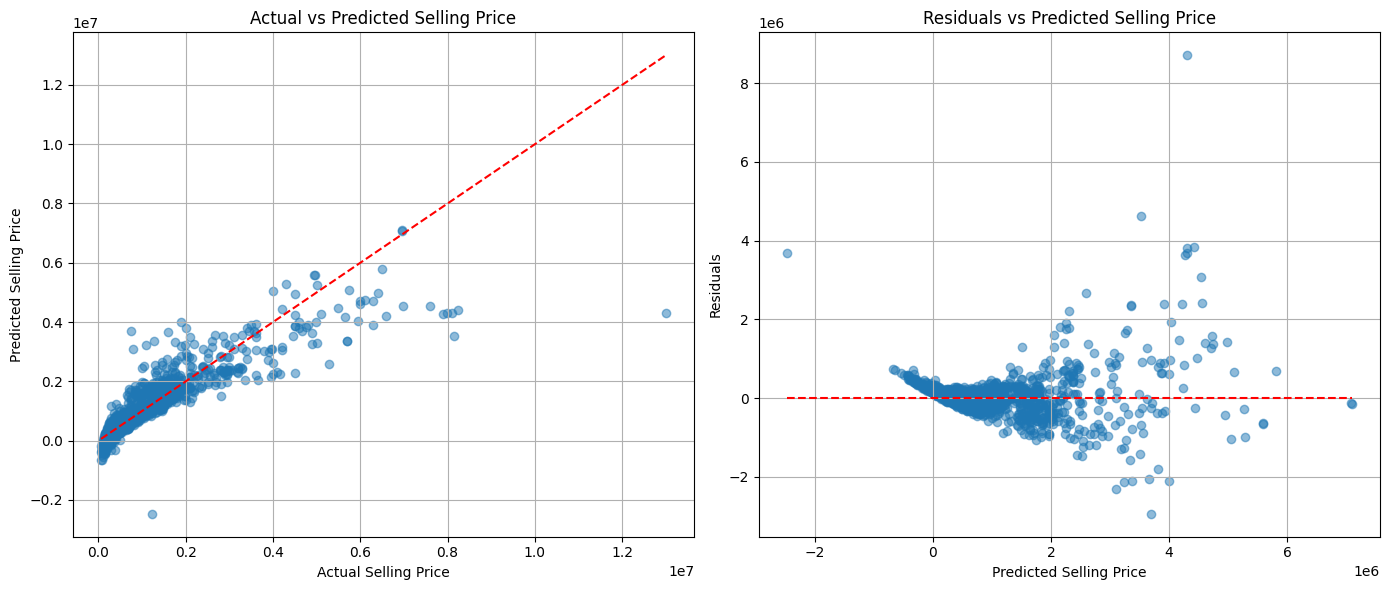

In [ ]:
y_test_flat = y_test_np.flatten()
y_pred_flat = y_pred_test.flatten()

plt.figure(figsize=(14, 6))

# Actual vs Predicted
plt.subplot(1, 2, 1)

plt.scatter(
    y_test_flat,
    y_pred_flat,
    alpha=0.5
)

plt.plot(
    [y_test_flat.min(), y_test_flat.max()],
    [y_test_flat.min(), y_test_flat.max()],
    'r--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.grid(True)

# Residual plot
residuals_flat = residuals.flatten()

plt.subplot(1, 2, 2)

plt.scatter(
    y_pred_flat,
    residuals_flat,
    alpha=0.5
)

plt.hlines(
    y=0,
    xmin=y_pred_flat.min(),
    xmax=y_pred_flat.max(),
    colors='r',
    linestyles='--'
)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Selling Price')
plt.grid(True)

plt.tight_layout()
plt.show()

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.